In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import os
import sys

if os.path.exists('notebooks'):
    os.chdir('notebooks')

# Titanic Survivability

Predict survival on the Titanic and get familiar with ML basics.

## Initialization

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from ml_utils import utils
from scipy import stats

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [34]:
df_train = pd.read_csv("../data/processed/X_train.csv")
df_test = pd.read_csv("../data/processed/X_test.csv")
df_train_y = pd.read_csv("../data/processed/Y_train.csv")
df_test_y = pd.read_csv("../data/processed/Y_test.csv")

## Exploratory Data Analysis

In [35]:
df_temp = df_train.copy()
df_temp['Survived'] = df_train_y

### Call Me By Your `Name`

This section is inspired by the excellent work of [Megan L. Risdal](https://www.kaggle.com/code/mrisdal/exploring-survival-on-the-titanic/report) and [Aldemuro M. A. Haris](https://www.kaggle.com/code/aldemuro/comparing-ml-algorithms-train-accuracy-90/notebook). Their analyses highlighted that a passenger's title can be a strong proxy for social status, which may correlate with survival. This same logic might apply to the `Cabin` feature, which we will explore later.

First, let's extract these titles from the `Name` column.

In [36]:
df_temp = (
    df_temp
    .assign(
        Title=lambda x: x['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    )
)

display(df_temp.head())
display(df_temp['Title'].unique())
display(utils.skim_data(df_temp))

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,Title
0,285,1,"Smith, Mr. Richard William",male,NaN,0,0,113056,26.0000,A19,S,0,Mr
1,862,2,"Giles, Mr. Frederick Edward",male,21.0,1,0,28134,11.5000,NaN,S,0,Mr
2,191,2,"Pinsky, Mrs. (Rosa)",female,32.0,0,0,234604,13.0000,NaN,S,1,Mrs
3,44,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.0,1,2,SC/Paris 2123,41.5792,NaN,C,1,Miss
4,742,1,"Cavendish, Mr. Tyrell William",male,36.0,1,0,19877,78.8500,C46,S,0,Mr


<ArrowStringArray>
[      'Mr',      'Mrs',     'Miss',   'Master',     'Capt',    'Major',
 'Jonkheer',      'Rev',      'Col',       'Ms',     'Mlle',       'Dr',
      'Mme', 'Countess']
Length: 14, dtype: str

Total duplicate rows: 0
DF shape: (712, 13)


,feature,dtype,null_%,negative_%,zero_%,min,max,n_unique,unique_%,sample_values
0,PassengerId,int64,0.000,0.0,0.0,2,891,712,100.00,"[285, 862, 191, 44, 742]"
1,Pclass,int64,0.000,0.0,0.0,1,3,3,0.42,"[1, 2, 3]"
2,Name,str,0.000,-,-,-,-,712,100.00,"[Smith, Mr. Richard William, Giles, Mr. Frederick Edward, Pinsky, Mrs. (Rosa), Laroche, Miss. Simonne Marie Anne Andree, Cavendish, Mr. Tyrell William]"
3,Sex,str,0.000,-,-,-,-,2,0.28,"[male, female]"
4,Age,float64,19.242,0.0,0.0,0.42,80.0,81,11.38,"[21.0, 32.0, 3.0, 36.0, 28.0]"
5,SibSp,int64,0.000,0.0,68.399,0,8,7,0.98,"[0, 1, 3, 4, 2]"
6,Parch,int64,0.000,0.0,75.983,0,6,7,0.98,"[0, 2, 1, 4, 3]"
7,Ticket,str,0.000,-,-,-,-,571,80.20,"[113056, 28134, 234604, SC/Paris 2123, 19877]"
8,Fare,float64,0.000,0.0,1.826,0.0,512.3292,222,31.18,"[26.0, 11.5, 13.0, 41.5792, 78.85]"
9,Cabin,str,77.528,-,-,-,-,119,16.71,"[A19, C46, B78, C93, C95]"


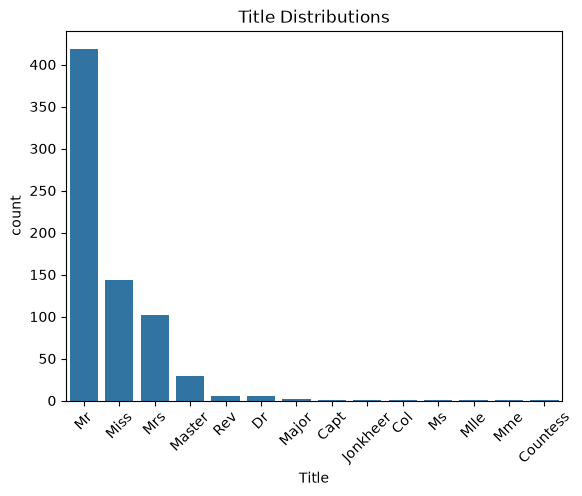

In [37]:
sns.countplot(data=df_temp, x='Title', order=df_temp['Title'].value_counts().index)
plt.title('Title Distributions')
plt.xticks(rotation=45)
plt.show()

The distribution shows a steep drop-off in frequency after the first few common titles. I'll use the count of `Master` as a threshold; any title less frequent will be consolidated into a single 'Rare' category. This approach simplifies the feature while retaining the information from the most common titles.

Before grouping, I will consolidate some similar titles. `Ms` is a variant of `Miss`, while `Mme` (Madame) and `Mlle` (Mademoiselle) are French equivalents of `Mrs` and `Miss`, respectively. These will be mapped to their common English counterparts to standardize the feature.

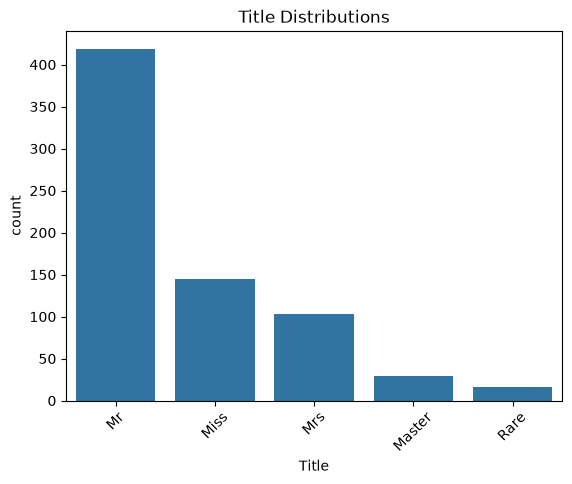

In [38]:
def clean_title(title):
    """A helper function to group titles."""
    if title in ['Ms', 'Mlle']:
        return 'Miss'
    if title in ['Mme']:
        return 'Mrs'
    return title

df_temp = (
    df_temp.copy()
    .assign(
        **{
            "Title": lambda x: (
                x["Name"]
                .str.extract(r' ([A-Za-z]+)\.', expand=False)
                .apply(clean_title)
            )
        }
    ).assign(
        **{
            "Title": lambda x: (
                x["Title"].replace(
                    (counts := x["Title"].value_counts())[counts < counts.get('Master', 0)].index,
                    'Rare'
                )
            )
        }
    )
)

sns.countplot(data=df_temp, x='Title', order=df_temp['Title'].value_counts().index)
plt.title('Title Distributions')
plt.xticks(rotation=45)
plt.show()

This process has cleaned and simplified the `Title` feature, making it more suitable for modeling. The same process has been integrated into a Scikit-Learn `Transformer` for future use.

### What's my `Age` again?

A well-known historical maritime protocol was the "women and children first" rule, also known as the Birkenhead Drill. This forms the basis of my hypothesis that `Age` is a critical feature for predicting survival.

With nearly 20% of `Age` values missing, imputation is necessary. A simple approach would be to use the mean or median of the entire dataset, but this would be too general. A more nuanced strategy, also seen in Aldemuro's work, is to impute `Age` based on the median value for each passenger's `Title` group.

To decide between the mean and median, we can visualize the age distribution for each title.

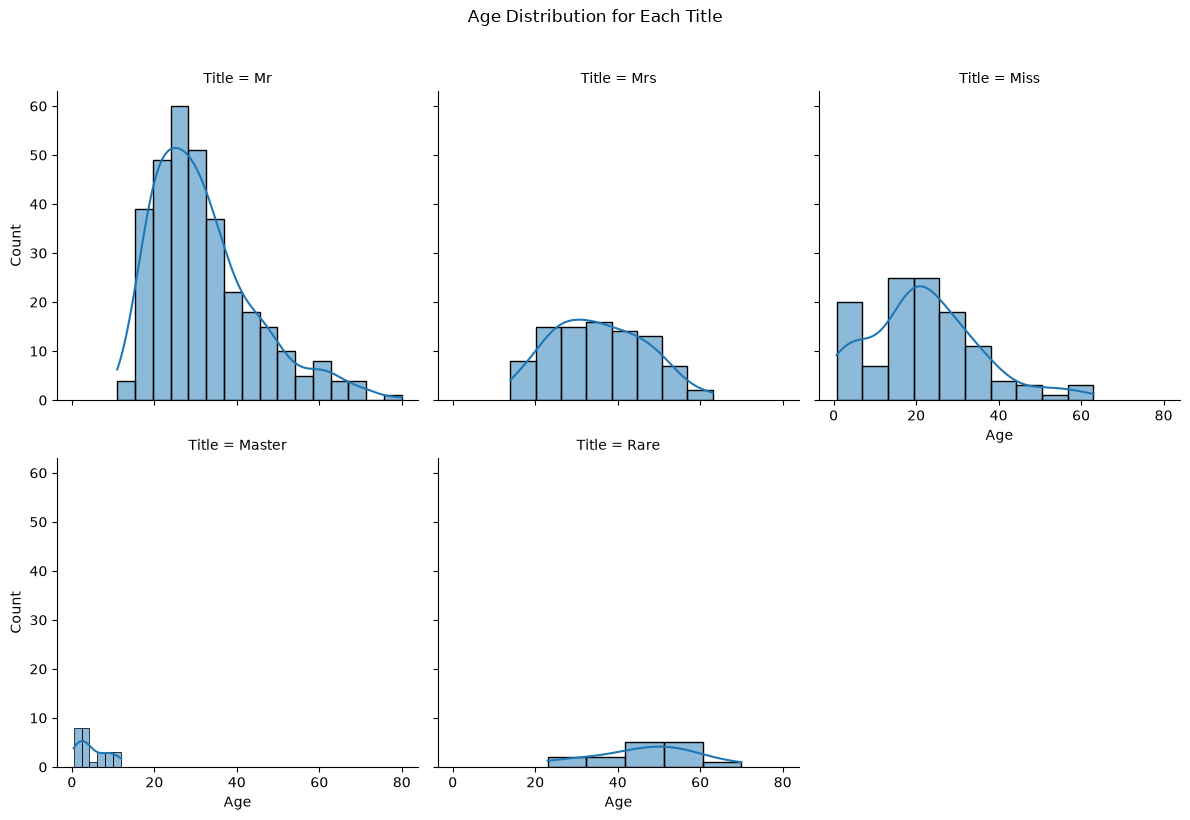

In [39]:
fg = sns.FacetGrid(df_temp, col='Title', col_wrap=3, height=4)
fg.map(sns.histplot, 'Age', kde=True)
fg.figure.suptitle('Age Distribution for Each Title', y=1.02)
plt.tight_layout()
plt.show()

The boxplots reveal that the age distributions within most title groups are skewed. Therefore, the *median* is a more robust measure of central tendency than the mean and is the better choice for imputation.

In [40]:
age_values = df_temp.groupby("Title")["Age"].transform("median")
df_temp["Age"] = df_temp["Age"].fillna(age_values)

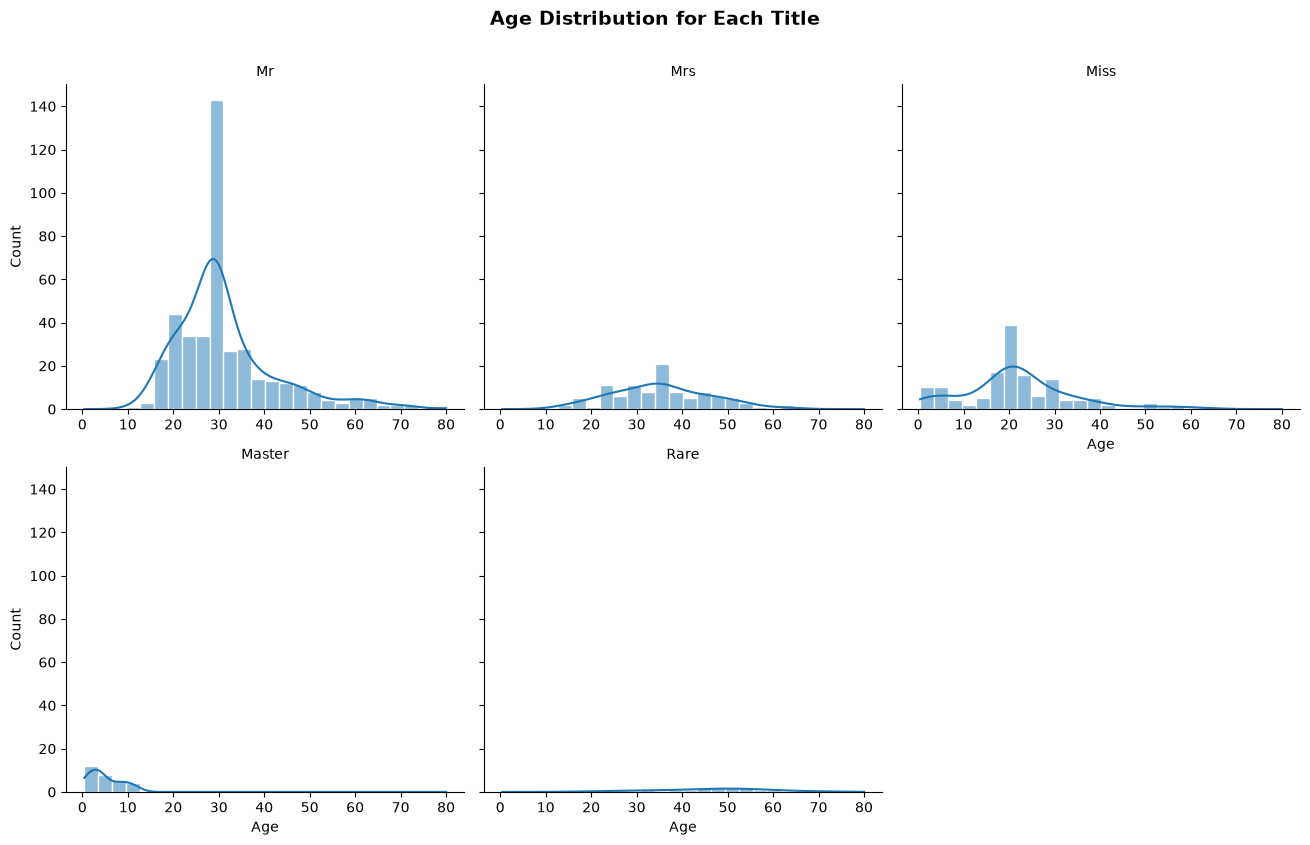

In [41]:
fg = sns.displot(
    data=df_temp, 
    x='Age', 
    col='Title', 
    col_wrap=3, 
    kind='hist', 
    kde=True,
    height=4, 
    aspect=1.1,
    color='#1f77b4',
    edgecolor='w',
    facet_kws={'sharex': False}
)

fg.set_titles("{col_name}")
fg.set_axis_labels("Age", "Count")
fg.figure.suptitle('Age Distribution for Each Title', y=1.05, fontsize=14, weight='bold')

plt.show()


With the missing `Age` values now intelligently filled, we can move to the next feature.

### Little `Cabin` on the Prairie

The Titanic was divided into seven decks, with First Class occupying the upper decks (A, B, and C) and other classes on the lower decks. Passengers on upper decks likely had faster and easier access to lifeboats, especially as the ship sank bow-first.

The `Cabin` feature is missing nearly 70% of its values. Rather than discarding it, we can hypothesize that the most important information is not the specific cabin number, but whether a passenger had a recorded cabin at all. The presence of a cabin number likely correlates strongly with being a First Class passenger.

Let's create a new binary feature, `HasCabin`, to capture this information.

In [42]:
df_temp = (
    df_temp
    .assign(
        HasCabin=lambda x: x['Cabin'].notna().astype(int)
    )
)

display(df_temp.sample(10, random_state=29))

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,Title,HasCabin
569,820,3,"Skoog, Master. Karl Thorsten",male,10.0,3,2,347088,27.9000,NaN,S,0,Master,0
322,705,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,NaN,S,0,Mr,0
87,94,3,"Dean, Mr. Bertram Frank",male,26.0,1,2,C.A. 2315,20.5750,NaN,S,0,Mr,0
537,406,2,"Gale, Mr. Shadrach",male,34.0,1,0,28664,21.0000,NaN,S,0,Mr,0
252,287,3,"de Mulder, Mr. Theodore",male,30.0,0,0,345774,9.5000,NaN,S,1,Mr,0
345,220,2,"Harris, Mr. Walter",male,30.0,0,0,W/C 14208,10.5000,NaN,S,0,Mr,0
251,624,3,"Hansen, Mr. Henry Damsgaard",male,21.0,0,0,350029,7.8542,NaN,S,0,Mr,0
510,245,3,"Attalah, Mr. Sleiman",male,30.0,0,0,2694,7.2250,NaN,C,0,Mr,0
564,514,1,"Rothschild, Mrs. Martin (Elizabeth L. Barrett)",female,54.0,1,0,PC 17603,59.4000,NaN,C,1,Mrs,0
511,497,1,"Eustis, Miss. Elizabeth Mussey",female,54.0,1,0,36947,78.2667,D20,C,1,Miss,1


Now, let's examine the relationship between this new feature and survival.

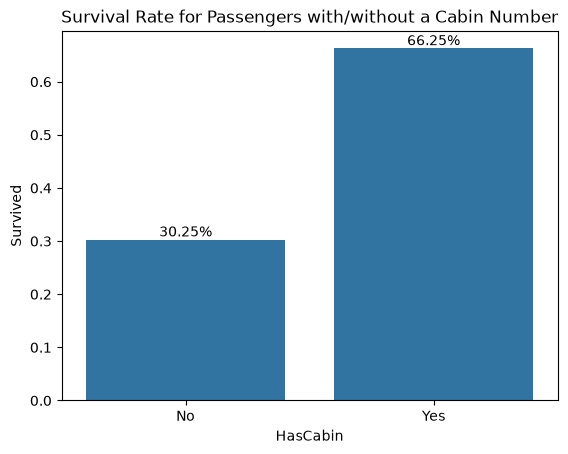

In [43]:
from typing import cast
from matplotlib.container import BarContainer

ax = sns.barplot(data=df_temp, x='HasCabin', y='Survived', errorbar=None)
bar_container = cast(BarContainer, ax.containers[0])
ax.bar_label(bar_container, fmt='{:.2%}')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No', 'Yes'])
ax.set_title('Survival Rate for Passengers with/without a Cabin Number')
plt.show()


The result is striking: over 66% of passengers with a recorded cabin survived, compared to just 30% of those without. This confirms that `HasCabin` is a potentially powerful predictive feature.

### Much Ado About Nothing

Let's review the state of our dataset after these transformations.

In [44]:
utils.skim_data(df_temp)

Total duplicate rows: 0
DF shape: (712, 14)


,feature,dtype,null_%,negative_%,zero_%,min,max,n_unique,unique_%,sample_values
0,PassengerId,int64,0.000,0.0,0.0,2,891,712,100.00,"[285, 862, 191, 44, 742]"
1,Pclass,int64,0.000,0.0,0.0,1,3,3,0.42,"[1, 2, 3]"
2,Name,str,0.000,-,-,-,-,712,100.00,"[Smith, Mr. Richard William, Giles, Mr. Frederick Edward, Pinsky, Mrs. (Rosa), Laroche, Miss. Simonne Marie Anne Andree, Cavendish, Mr. Tyrell William]"
3,Sex,str,0.000,-,-,-,-,2,0.28,"[male, female]"
4,Age,float64,0.000,0.0,0.0,0.42,80.0,81,11.38,"[29.0, 21.0, 32.0, 3.0, 36.0]"
5,SibSp,int64,0.000,0.0,68.399,0,8,7,0.98,"[0, 1, 3, 4, 2]"
6,Parch,int64,0.000,0.0,75.983,0,6,7,0.98,"[0, 2, 1, 4, 3]"
7,Ticket,str,0.000,-,-,-,-,571,80.20,"[113056, 28134, 234604, SC/Paris 2123, 19877]"
8,Fare,float64,0.000,0.0,1.826,0.0,512.3292,222,31.18,"[26.0, 11.5, 13.0, 41.5792, 78.85]"
9,Cabin,str,77.528,-,-,-,-,119,16.71,"[A19, C46, B78, C93, C95]"


The dataset is almost clean. The only remaining missing values are two entries (0.2%) in the `Embarked` column. Let's examine the distribution of this feature.

In [45]:
df_temp.loc[lambda x: x['Embarked'].isna()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,Title,HasCabin
130,62,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,1,Miss,1
690,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,1,Mrs,1


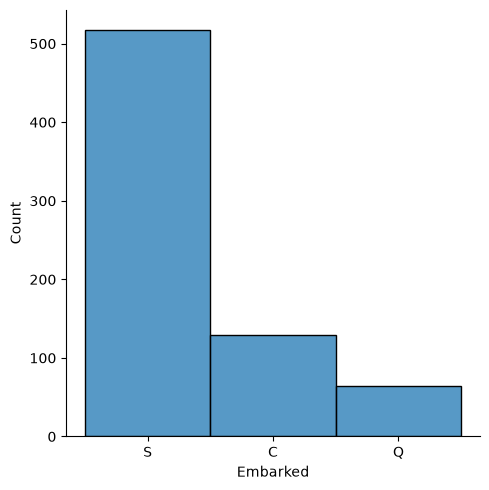

In [46]:
sns.displot(
    df_temp, x='Embarked', binwidth=3,
    facet_kws=dict(margin_titles=True)
)

The overwhelming majority of passengers embarked at Southampton (`S`). Given this distribution, it is reasonable to fill the two missing values with the mode, `S`.

In [47]:
df_temp = (
    df_temp
    .assign(
        Embarked=lambda x: x['Embarked'].fillna('S')
    )
)

In [48]:
utils.skim_data(df_temp)

Total duplicate rows: 0
DF shape: (712, 14)


,feature,dtype,null_%,negative_%,zero_%,min,max,n_unique,unique_%,sample_values
0,PassengerId,int64,0.000,0.0,0.0,2,891,712,100.00,"[285, 862, 191, 44, 742]"
1,Pclass,int64,0.000,0.0,0.0,1,3,3,0.42,"[1, 2, 3]"
2,Name,str,0.000,-,-,-,-,712,100.00,"[Smith, Mr. Richard William, Giles, Mr. Frederick Edward, Pinsky, Mrs. (Rosa), Laroche, Miss. Simonne Marie Anne Andree, Cavendish, Mr. Tyrell William]"
3,Sex,str,0.000,-,-,-,-,2,0.28,"[male, female]"
4,Age,float64,0.000,0.0,0.0,0.42,80.0,81,11.38,"[29.0, 21.0, 32.0, 3.0, 36.0]"
5,SibSp,int64,0.000,0.0,68.399,0,8,7,0.98,"[0, 1, 3, 4, 2]"
6,Parch,int64,0.000,0.0,75.983,0,6,7,0.98,"[0, 2, 1, 4, 3]"
7,Ticket,str,0.000,-,-,-,-,571,80.20,"[113056, 28134, 234604, SC/Paris 2123, 19877]"
8,Fare,float64,0.000,0.0,1.826,0.0,512.3292,222,31.18,"[26.0, 11.5, 13.0, 41.5792, 78.85]"
9,Cabin,str,77.528,-,-,-,-,119,16.71,"[A19, C46, B78, C93, C95]"


Now that the data is cleaned and new features are engineered, we can dive into a deeper exploration.

### Outliers

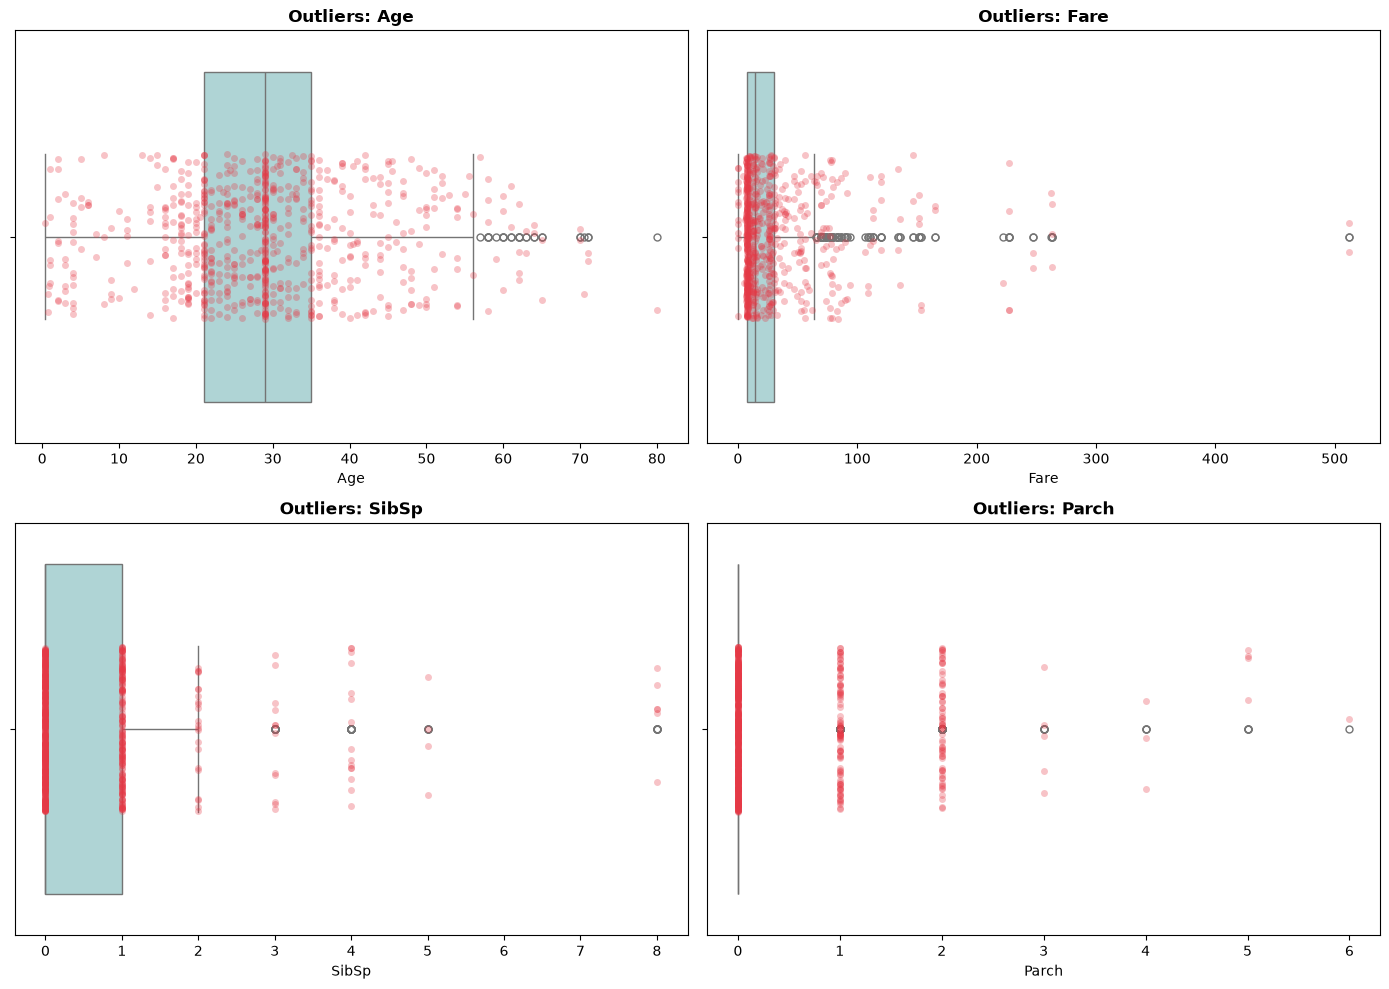

=== Outlier Statistics Analysis ===

--- Column: Age ---
[IQR] Limits: 0.00 s/d 56.00
[IQR] Total Outliers: 27 out of 712 data (3.79%)
[Z-Score] Total Outliers (Z > 3): 6 out of 712 data (0.84%)

--- Column: Fare ---
[IQR] Limits: -26.01 s/d 64.41
[IQR] Total Outliers: 89 out of 712 data (12.50%)
[Z-Score] Total Outliers (Z > 3): 13 out of 712 data (1.83%)

--- Column: SibSp ---
[IQR] Limits: -1.50 s/d 2.50
[IQR] Total Outliers: 37 out of 712 data (5.20%)
[Z-Score] Total Outliers (Z > 3): 25 out of 712 data (3.51%)

--- Column: Parch ---
[IQR] Limits: 0.00 s/d 0.00
[IQR] Total Outliers: 171 out of 712 data (24.02%)
[Z-Score] Total Outliers (Z > 3): 13 out of 712 data (1.83%)


In [49]:
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    clean_data = df_temp[col].dropna()
    sns.boxplot(x=clean_data, ax=axes[i], color='#a8dadc', fliersize=5)
    sns.stripplot(x=clean_data, ax=axes[i], color='#e63946', alpha=0.3, jitter=0.2)
    axes[i].set_title(f'Outliers: {col}', fontsize=12, weight='bold')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

print("=== Outlier Statistics Analysis ===")
for col in numerical_cols:
    print(f"\n--- Column: {col} ---")
    series = df_temp[col].dropna()
    total_data = len(series)

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outliers_iqr = series[(series < lower_bound) | (series > upper_bound)]
    print(f"[IQR] Limits: {lower_bound:.2f} s/d {upper_bound:.2f}")
    print(f"[IQR] Total Outliers: {len(outliers_iqr)} out of {total_data} data ({len(outliers_iqr)/total_data:.2%})")

    z_scores = np.abs(stats.zscore(series.to_numpy()))  # type: ignore
    outliers_z = series[z_scores > 3]
    print(f"[Z-Score] Total Outliers (Z > 3): {len(outliers_z)} out of {total_data} data ({len(outliers_z)/total_data:.2%})")

### Univariate Analysis

#### Numerical Features

=== NUMERICAL SKEWNESS REPORT ===
Age      -> Skewness:   0.50 | Shape: Right-Skewed (Positive Tail)
Fare     -> Skewness:   4.94 | Shape: Right-Skewed (Positive Tail)
SibSp    -> Skewness:   3.72 | Shape: Right-Skewed (Positive Tail)
Parch    -> Skewness:   2.76 | Shape: Right-Skewed (Positive Tail)


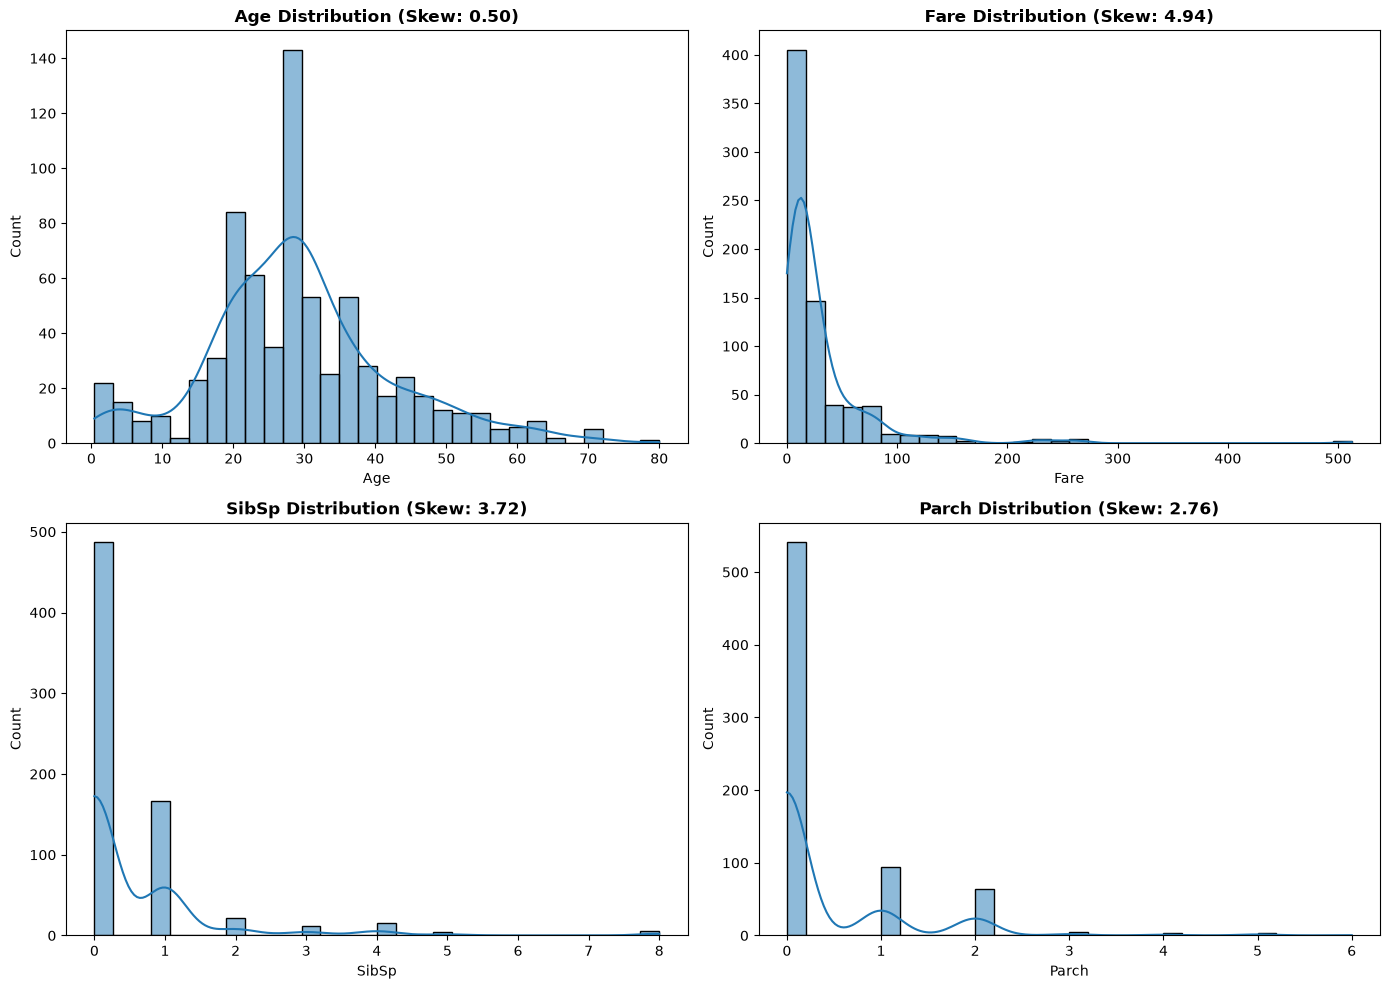

In [50]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print("=== NUMERICAL SKEWNESS REPORT ===")
for i, col in enumerate(num_cols):
    clean_series = df_temp[col].dropna()
    sns.histplot(data=clean_series, kde=True, ax=axes[i], color='#1f77b4', bins=30) # type: ignore
    skew_val: float = float(clean_series.skew()) # type: ignore

    if abs(skew_val) < 0.5:
        shape_desc = "Approximately Symmetric (Normal)"
    elif skew_val >= 0.5:
        shape_desc = "Right-Skewed (Positive Tail)"
    else:
        shape_desc = "Left-Skewed (Negative Tail)"

    print(f"{col:<8} -> Skewness: {skew_val:>6.2f} | Shape: {shape_desc}")
    axes[i].set_title(f'{col} Distribution (Skew: {skew_val:.2f})', fontsize=12, weight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()


#### Categorical Features


=== CATEGORICAL DISTRIBUTION REPORT ===

--- Distribution of Pclass ---
  3         :  396 passengers (55.62%)
  1         :  169 passengers (23.74%)
  2         :  147 passengers (20.65%)

--- Distribution of Sex ---
  male      :  462 passengers (64.89%)
  female    :  250 passengers (35.11%)

--- Distribution of Embarked ---
  S         :  519 passengers (72.89%)
  C         :  129 passengers (18.12%)
  Q         :   64 passengers (8.99%)

--- Distribution of Survived ---
  0         :  439 passengers (61.66%)
  1         :  273 passengers (38.34%)


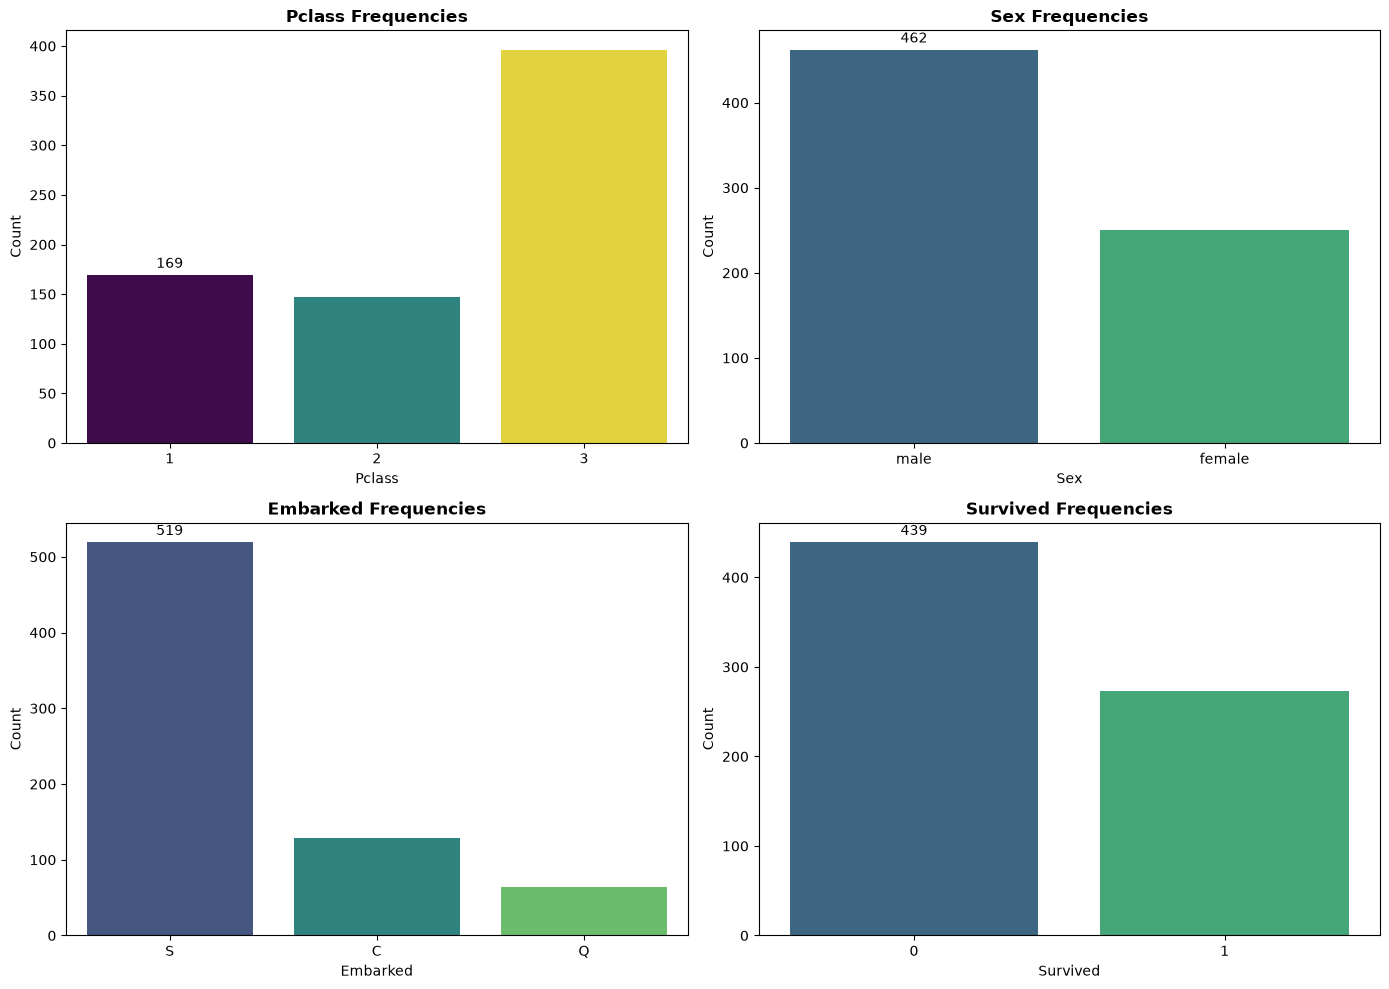

In [51]:
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Survived']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print("\n=== CATEGORICAL DISTRIBUTION REPORT ===")
for i, col in enumerate(cat_cols):
    counts = df_temp[col].value_counts(dropna=False)
    percentages = df_temp[col].value_counts(normalize=True, dropna=False)

    print(f"\n--- Distribution of {col} ---")
    for val in counts.index:
        val_str = "Missing (NaN)" if pd.isna(val) else str(val)
        print(f"  {val_str:<10}: {counts[val]:>4} passengers ({percentages[val]:.2%})")

    sns.countplot(data=df_temp, x=col, ax=axes[i], palette='viridis', hue=col, legend=False)

    from typing import cast
    from matplotlib.container import BarContainer
    bar_container = cast(BarContainer, axes[i].containers[0])
    axes[i].bar_label(bar_container, fmt='%d', label_type='edge', padding=3)
    
    axes[i].set_title(f'{col} Frequencies', fontsize=12, weight='bold')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()


### Bivariate Analysis

#### Numeric vs Numeric

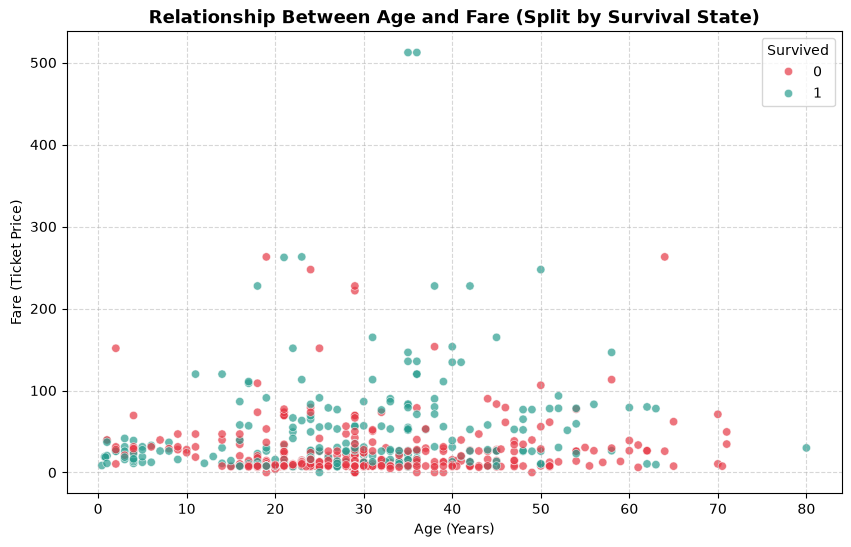

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_temp,
    x='Age', 
    y='Fare', 
    hue='Survived', 
    palette={0: '#e63946', 1: '#2a9d8f'}, 
    alpha=0.7
)

plt.title('Relationship Between Age and Fare (Split by Survival State)', fontsize=13, weight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Fare (Ticket Price)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#### Categorical vs Numeric

/var/folders/34/_j3kcpxd38lfbdvtp0clnhrw0000gn/T/ipykernel_66343/895839598.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])


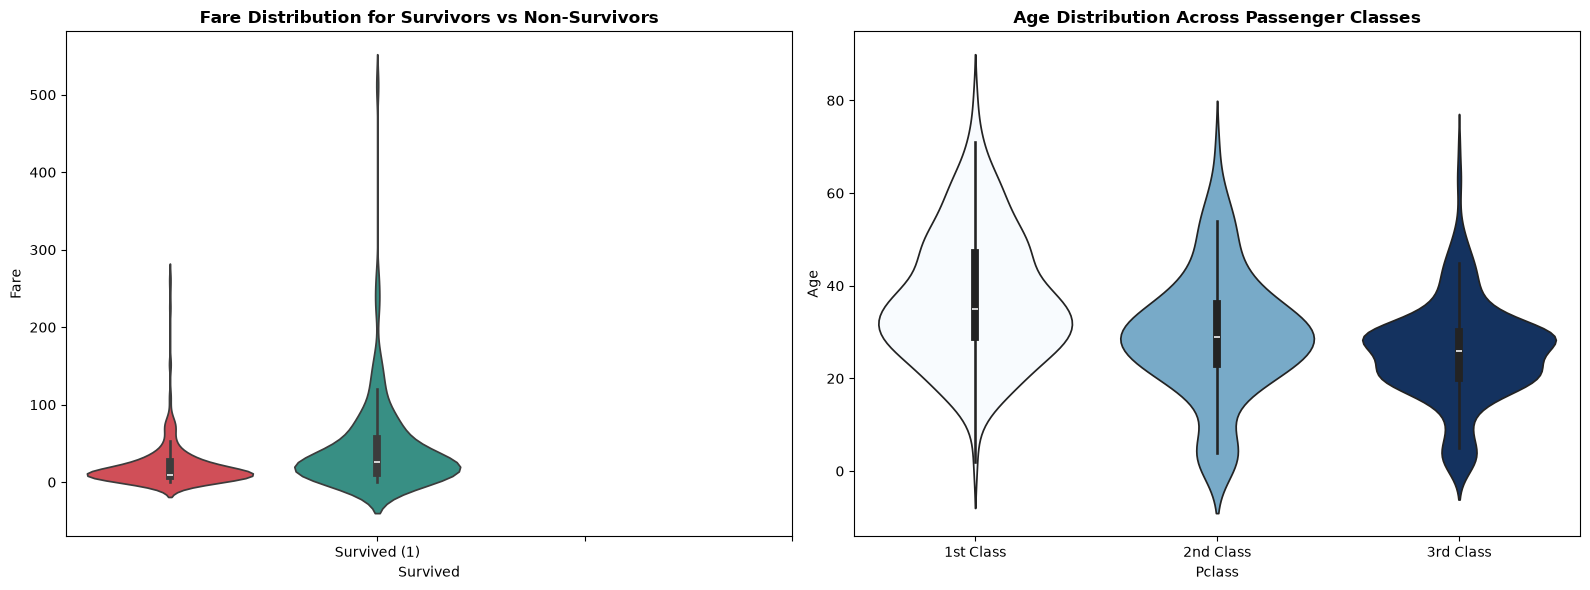

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.violinplot(
    data=df_temp, 
    x='Survived', 
    y='Fare', 
    ax=axes[0], 
    palette={0: '#e63946', 1: '#2a9d8f'},
    hue='Survived',
    legend=False
)
axes[0].set_title('Fare Distribution for Survivors vs Non-Survivors', fontsize=12, weight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Perished (0)', 'Survived (1)'])

sns.violinplot(
    data=df_temp, 
    x='Pclass', 
    y='Age', 
    ax=axes[1], 
    palette='Blues',
    hue='Pclass',
    legend=False
)
axes[1].set_title('Age Distribution Across Passenger Classes', fontsize=12, weight='bold')
axes[0].set_xticks([1, 2, 3])
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

plt.tight_layout()
plt.show()

#### Categorical vs Categorical

/var/folders/34/_j3kcpxd38lfbdvtp0clnhrw0000gn/T/ipykernel_66343/2293664903.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['Southampton (S)', 'Cherbourg (C)', 'Queenstown (Q)'])


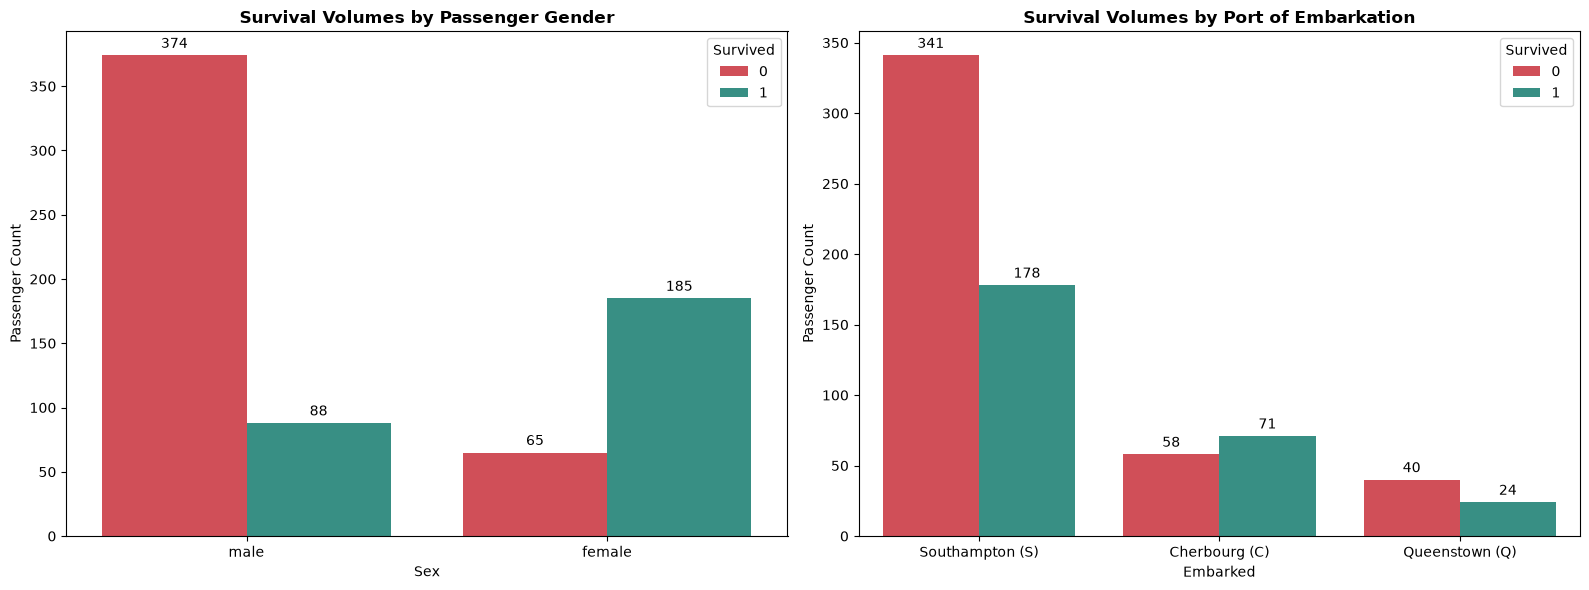

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data=df_temp, 
    x='Sex', 
    hue='Survived', 
    palette={0: '#e63946', 1: '#2a9d8f'}, 
    ax=axes[0]
)
axes[0].set_title('Survival Volumes by Passenger Gender', fontsize=12, weight='bold')
axes[0].set_ylabel('Passenger Count')

for container in axes[0].containers:
    axes[0].bar_label(cast(BarContainer, container), fmt='%d', padding=3)

sns.countplot(
    data=df_temp, 
    x='Embarked', 
    hue='Survived', 
    palette={0: '#e63946', 1: '#2a9d8f'}, 
    ax=axes[1]
)
axes[1].set_title('Survival Volumes by Port of Embarkation', fontsize=12, weight='bold')
axes[1].set_ylabel('Passenger Count')
axes[1].set_xticklabels(['Southampton (S)', 'Cherbourg (C)', 'Queenstown (Q)'])

for container in axes[1].containers:
    axes[1].bar_label(cast(BarContainer, container), fmt='%d', padding=3)

plt.tight_layout()
plt.show()

### Multivariate Analysis

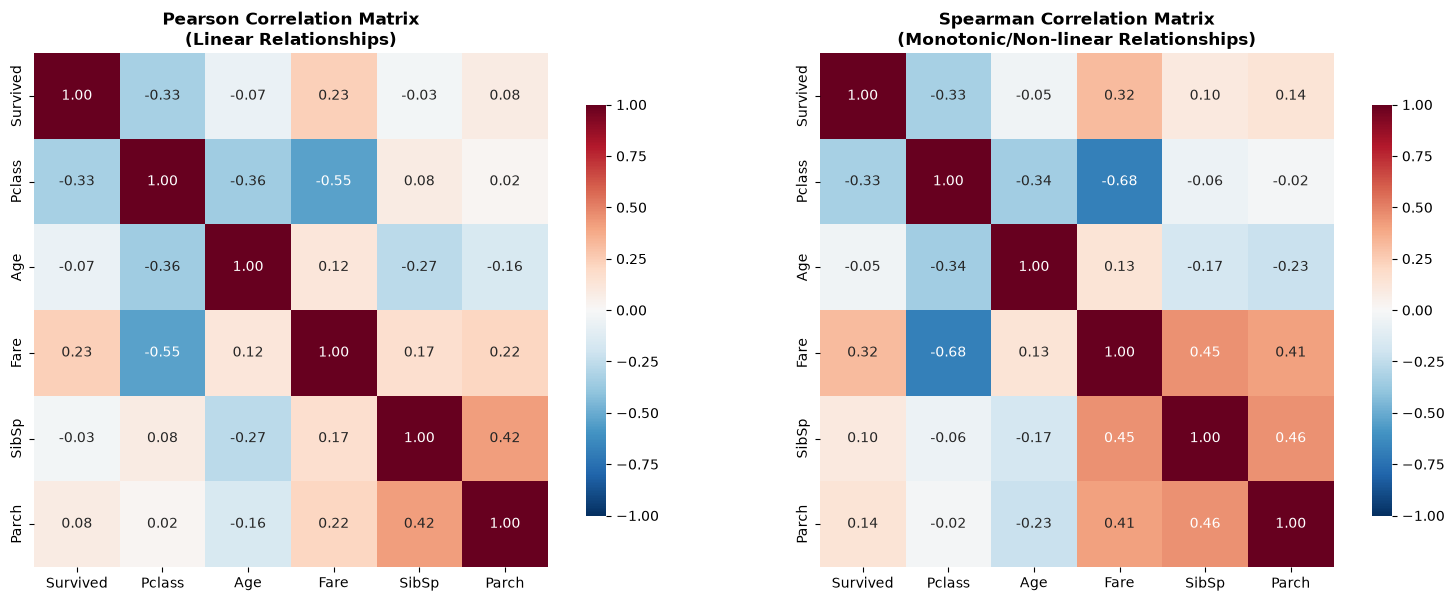

In [55]:
corr_features = ['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']
corr_data = df_temp[corr_features]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrix A: Pearson (Linear)
pearson_matrix = corr_data.corr(method='pearson')
sns.heatmap(
    pearson_matrix, annot=True, fmt=".2f", cmap='RdBu_r', 
    vmin=-1, vmax=1, square=True, ax=axes[0], cbar_kws={"shrink": .8}
)
axes[0].set_title('Pearson Correlation Matrix\n(Linear Relationships)', fontsize=12, weight='bold')

# Matrix B: Spearman (Non-linear / Rank)
spearman_matrix = corr_data.corr(method='spearman')
sns.heatmap(
    spearman_matrix, annot=True, fmt=".2f", cmap='RdBu_r', 
    vmin=-1, vmax=1, square=True, ax=axes[1], cbar_kws={"shrink": .8}
)
axes[1].set_title('Spearman Correlation Matrix\n(Monotonic/Non-linear Relationships)', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

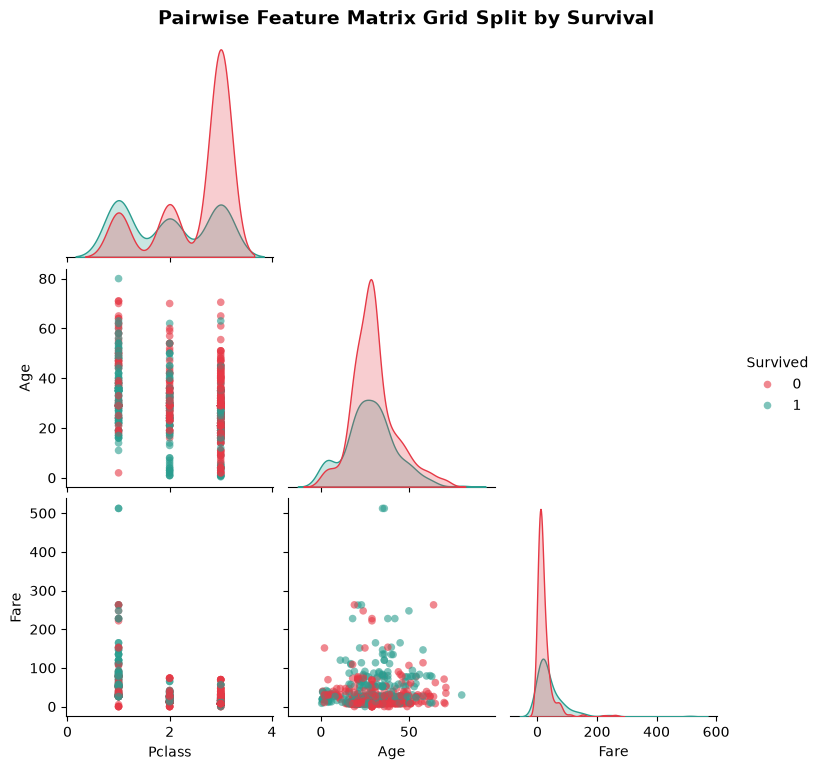

In [56]:
pairplot_features = ['Survived', 'Pclass', 'Age', 'Fare']
g = sns.pairplot(
    data=df_temp[pairplot_features], 
    hue='Survived', 
    palette={0: '#e63946', 1: '#2a9d8f'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'none'},
    corner=True
)

g.figure.suptitle('Pairwise Feature Matrix Grid Split by Survival', y=1.02, fontsize=14, weight='bold')
plt.show()

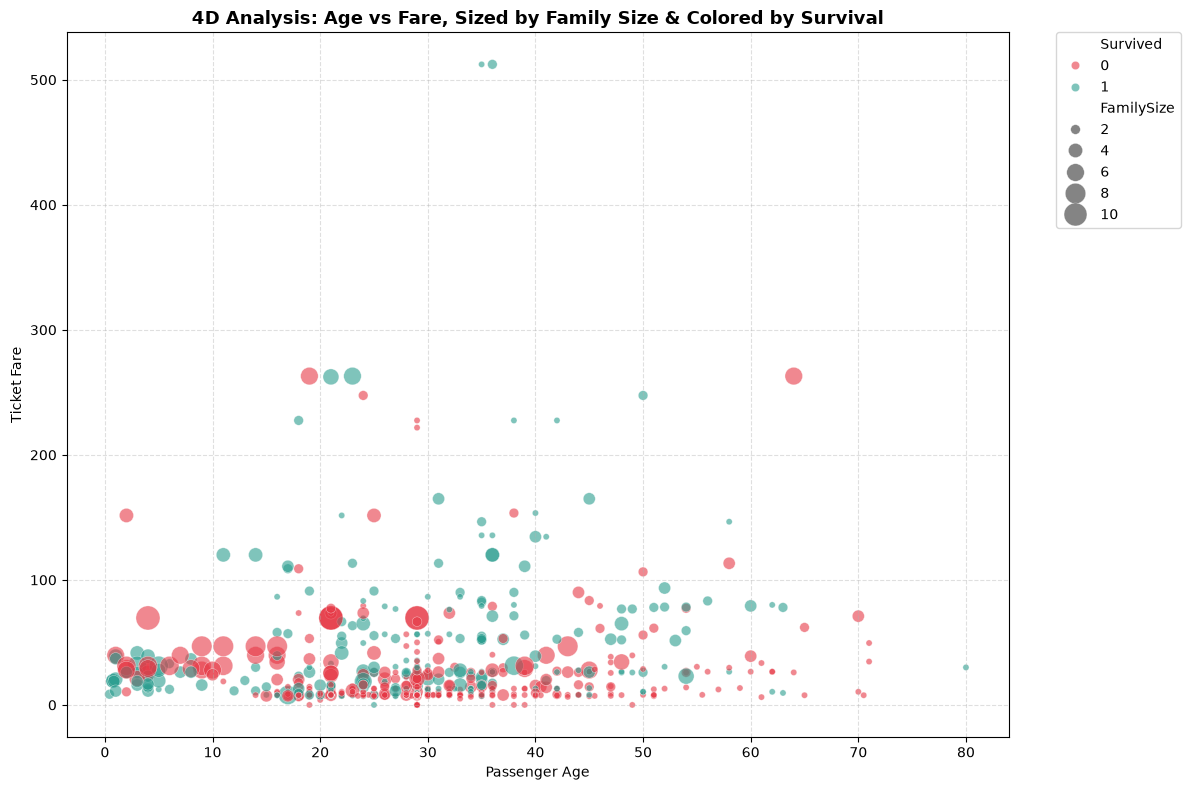

In [57]:
df_multivariate = df_temp.copy()
df_multivariate['FamilySize'] = df_multivariate['SibSp'] + df_multivariate['Parch'] + 1

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_multivariate,
    x='Age',
    y='Fare',
    hue='Survived',
    size='FamilySize',
    sizes=(20, 300),
    palette={0: '#e63946', 1: '#2a9d8f'},
    alpha=0.6,
    edgecolor='w'
)

plt.title('4D Analysis: Age vs Fare, Sized by Family Size & Colored by Survival', fontsize=13, weight='bold')
plt.xlabel('Passenger Age')
plt.ylabel('Ticket Fare')
plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

---

In [58]:
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = 'kaggle_secrets' in sys.modules or os.path.exists('/kaggle')
IN_CLOUD = IN_COLAB or IN_KAGGLE

if IN_CLOUD:
    print("☁️ Cloud environment detected. Preparing to push changes to GitHub...")
    GIT_EMAIL = "dev.rbennum@gmail.com"
    GIT_NAME = "Bening R."
    COMMIT_MESSAGE = f"{""}"

    !git config --global user.email "{GIT_EMAIL}"
    !git config --global user.name "{GIT_NAME}"

    print("🔄 Staging files...")
    !git add .
    status = !git status --porcelain
    if status:
        print("📝 Committing changes...")
        !git commit -m "{COMMIT_MESSAGE}"
        print("🚀 Pushing to GitHub (Main Branch)...")
        !git push origin main
        print("✨ Success! Your cloud changes are now safely backed up on GitHub.")
    else:
        print("ℹ️ No changes detected in the notebooks. GitHub is already up to date.")
else:
    print("💻 Running locally on MacBook. Use your standard Git terminal or VS Code UI to push your work!")

💻 Running locally on MacBook. Use your standard Git terminal or VS Code UI to push your work!
